# Simulations

Here we illustrate how to run simulations, using the ``atomsmltr.simulation.simulator`` subpackage

We only provide minimal examples here. Please have a look at the examples in the **atomic physic** section for more examples.

## Minimal example of a simulation

Here is a very simple example, where we only include a pair of lasers along z (modelled as plane waves), and launch one ytterbium atom with an initial speed of 100 m/s along z.

We use the simulator based on Scipy's ``solve_IVP`` method, namely ``ScipyIVP_3D``. When we only need to perform one simulation, the easiest is to use the ``integrate()`` method.

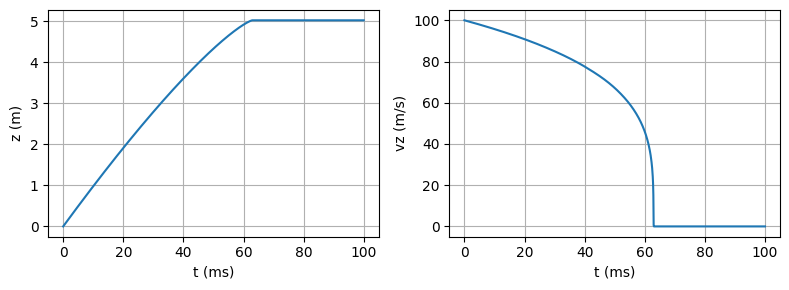

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from atomsmltr.environment import PlaneWaveLaserBeam
from atomsmltr.atoms import Ytterbium
from atomsmltr.simulation import Configuration, ScipyIVP_3D

# - setup atom
atom = Ytterbium()
main = atom.trans["main"] # get transition, to help setting up lasers

# - setup laser
laser_1 = PlaneWaveLaserBeam()
laser_1.direction = (0, 0, 1)
laser_1.set_power_from_I(main.Isat) # set power to reach Isat
laser_1.tag = "las1"

laser_2 = laser_1.copy() # create a copy
laser_2.direction = (0, 0, -1)  # propagating in opposite direction
laser_2.tag = "las2"

# - config
config = Configuration()
config.atom = atom
config += laser_1, laser_2
config.add_atomlight_coupling("las1", "main", -0.5 * main.Gamma)
config.add_atomlight_coupling("las2", "main", -0.5 * main.Gamma)

# - simulation
sim = ScipyIVP_3D(config=config)
t = np.linspace(0, 0.1, 1000)  # timesteps for integration
u0 = (0, 0, 0, 0, 0, 100)  # atom starts with vz=100m/s
res = sim.integrate(u0, t)

# plot
fix, axes = plt.subplots(1, 2, figsize=(8, 3), tight_layout=True)
axes[0].plot(res.t * 1e3, res.y[2])
axes[0].set_ylabel("z (m)")
axes[1].plot(res.t * 1e3, res.y[5])
axes[1].set_ylabel("vz (m/s)")
for ax in axes:
    ax.set_xlabel("t (ms)")
    ax.grid()

## Parallel computation

The simulator makes it easy to perform several simulations in parallel. For that, one has to provide a list of initial conditions ``u0_list`` and use the ``run()`` method :

In [42]:
# - simulation
# using the same configuration as before
sim = ScipyIVP_3D(config=config)
t = np.linspace(0, 0.1, 1000)  # timesteps for integration

# prepare initial conditions
vz_list = np.linspace(1, 130, 100)
u0_list = [(0,0,0,0,0,vz) for vz in vz_list]

# run
sim.u0_list = u0_list
res_coll = sim.run(t, npools=5, verbose=True)

100%|██████████| 100/100 [00:01<00:00, 97.59it/s]


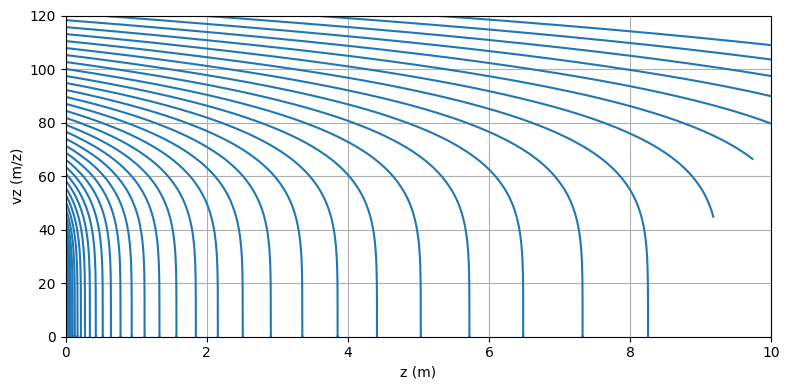

In [43]:
# plot
plt.figure(figsize=(8, 4), tight_layout=True)
for res in res_coll[::2]:
    plt.plot(res.y[2], res.y[5], color="C0")
plt.xlabel("z (m)")
plt.ylabel("vz (m/z)")
plt.xlim(0, 10)
plt.ylim(0, 120)
plt.grid()
plt.show()

## Use zones to stop the simulation

One can use zones to make the simulation stop. Depending on the simulator used, the simulation might stop as soon as an atom steps outside from the simulation space, or slightly afterwards (this is the case with Scipy's ``solve_ivp`` method, for some reason that I do not fully grasp).

To test that, let's make a stupid simulation with atoms flying around freely

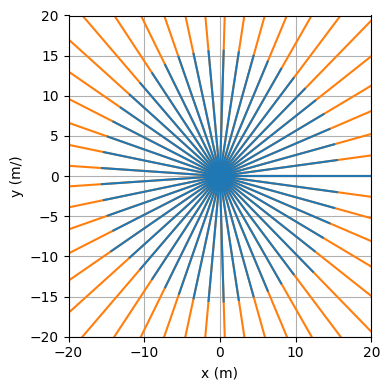

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from atomsmltr.simulation import Configuration, ScipyIVP_3D
from atomsmltr.environment import Limits
from atomsmltr.atoms import Ytterbium

# atom
atom = Ytterbium()

# zones
xlim = Limits(-10, 10, axis=0, target="position", action="stop")
ylim = Limits(-10, 10, axis=1, target="position", action="stop")

# config
config = Configuration()
config.atom = atom
config.add_objects([xlim, ylim])

# simulator

sim = ScipyIVP_3D(config)

# set initial conditions
t = np.linspace(0, 10, 1000)
theta_list = np.linspace(0, 2 * np.pi, 50)
u0 = [(0, 0, 0, 10 * np.cos(th), 10 * np.sin(th), 0) for th in theta_list]

# run
res_coll = sim.run(t, u0, npools=5)

# compare with case without zones
config.rm_all_zones()
sim.config = config
res_coll_nozones = sim.run(t, u0, npools=5)

# plot
plt.figure(figsize=(4, 4), tight_layout=True)
for res in res_coll_nozones:
    plt.plot(res.y[0], res.y[1], color="C1")
for res in res_coll:
    plt.plot(res.y[0], res.y[1], color="C0")
plt.xlabel("x (m)")
plt.ylabel("y (m/)")
plt.xlim(-20, 20)
plt.ylim(-20, 20)
plt.grid()
plt.show()

As explained above, here the simulation should stop as soon as the atom exits the (-10, 10) zone in x or y, but for some reason solve_ivp integrates it a bit beyond. This might be due to the fact that the feature we use (`events`) is not really meant for that..

cf. https://docs.scipy.org/doc/scipy/reference/generated/scipy.integrate.solve_ivp.html 

## Use zone tags to check atoms final state

The ``Zone`` objects have two tags, ``in_tag`` and ``out_tag``, that will be automatically assigned to atoms at the end of the simulation, depending on their final state.

Note that the use of tags is independant of the ``action`` associated with the ``Zone`` : it will work both with ``action`` set to ``"stop"``; which stops the simulation outside of the zone, or with ``action`` set to ``"ignore"``. The latter case is useful to check the final state of the atom without stopping the simulation.

Again, a dummy illustration with free-flying atoms:

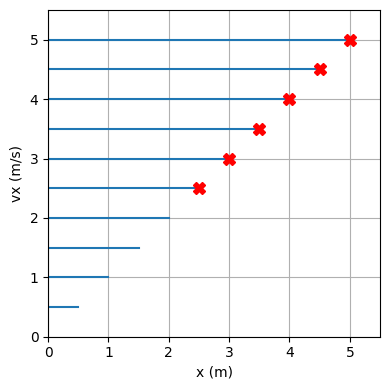

In [17]:
import numpy as np
import matplotlib.pyplot as plt

from atomsmltr.simulation import Configuration, ScipyIVP_3D
from atomsmltr.environment import Limits
from atomsmltr.atoms import Ytterbium

# atom
atom = Ytterbium()

# zones
xlim = Limits(-10, 2.5, axis=0, target="position", action="ignore", out_tag="out")

# config
config = Configuration()
config.atom = atom
config.add_objects([xlim, ylim])

# simulator

sim = ScipyIVP_3D(config)

# set initial conditions
t = np.linspace(0, 1, 100)
v_list = np.linspace(0.5, 5, 10)
u0 = [(0, 0, 0, v, 0, 0) for v in v_list]

# run
res_coll = sim.run(t, u0, npools=5)

# plot
plt.figure(figsize=(4, 4), tight_layout=True)
for res in res_coll:
    plt.plot(res.y[0], res.y[3], color="C0")
    # check if atom is out
    if "out" in res.tags:
        plt.plot(res.y[0][-1], res.y[3][-1], "X", color="r", markersize=8)
plt.xlabel("x (m)")
plt.ylabel("vx (m/s)")
plt.xlim(0, 5.5)
plt.ylim(0, 5.5)
plt.grid()
plt.show()